# 01 · Data catalogue: what every file is

**Goal of this notebook.** Before any modelling we need to know exactly what we have. For each file this notebook answers three questions: what is it, what are its key variables, and how many people and visits does it cover?

**Why this comes first.** Every later decision (which people go in the cohort, what we predict, which model is realistic) depends on these counts. If we skip this step we risk designing a model for data we do not have.

**Privacy rule used in every notebook.** The data are covered by the NACC data use agreement. These notebooks only ever print counts, percentages and summary statistics. They never show a row that belongs to one person, and never show a NACCID. If you add a cell, do not use `df.head()` on participant data.

**Where definitions come from.** Variable meanings follow the NACC Researcher's Data Dictionary (RDD) for the Uniform Data Set and the SCAN PET documentation. The code counts were checked against the file itself. Before you cite a definition in your report, confirm it in the Freeze 74 RDD.

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

nu.set_style()
pd.set_option("display.max_colwidth", 200, "display.width", 200)
audit = json.loads(nu.AUDIT_JSON.read_text())

## 1. The files

There are ten tables and one folder of images. The numbers below were produced by `scripts/audit_data.py`, which reads every file once.

In [2]:
WHAT = {
    "investigator_ftldlbd_nacc74.csv": ("Main clinical table (Uniform Data Set + FTLD and LBD modules + neuropathology + genetics flags)",
        "One row per clinic visit. Demographics, medical history, blood pressure, medications, cognitive tests, CDR, diagnosis, APOE."),
    "investigator_clariti_edc_nacc74.csv": ("CLARiTI study tracking",
        "One row per CLARiTI enrolment. Dates of consent, blood draw, PET and MRI, and whether results were returned. Administrative; not a source of features."),
    "investigator_scan_clariti_amyloidpetgaain_nacc74.csv": ("SCAN amyloid PET, summary",
        "One row per amyloid scan: Centiloids, amyloid positive/negative, summary SUVR, tracer, QC."),
    "investigator_scan_clariti_amyloidpetnpdka_nacc74.csv": ("SCAN amyloid PET, regional",
        "Same scans as above with SUVR in about 160 brain regions."),
    "investigator_scan_clariti_taupetnpdka_nacc74.csv": ("SCAN tau PET, regional",
        "One row per tau scan: meta-temporal SUVR, entorhinal SUVR and about 160 regional SUVRs."),
    "investigator_scan_clariti_fdgpetnpdka_nacc74.csv": ("SCAN FDG PET, regional",
        "One row per FDG (glucose metabolism) scan: meta-ROI SUVR and regional SUVRs."),
    "investigator_scan_clariti_petqc_nacc74.csv": ("SCAN PET quality control",
        "One row per PET image received: tracer, scanner model, pass/fail. This is the list that links image IDs to participants."),
    "investigator_scan_mp_amyloidpetgaain_nacc74.csv": ("Mixed-protocol amyloid PET, summary",
        "Older scans (2005-2023) acquired under each centre's own protocol, reprocessed centrally: Centiloids, status, SUVR."),
    "investigator_scan_mp_amyloidpetnpdka_nacc74.csv": ("Mixed-protocol amyloid PET, regional", "Regional SUVRs for the same older scans."),
    "investigator_scan_mp_taupetnpdka_nacc74.csv": ("Mixed-protocol tau PET, regional", "Older tau scans: meta-temporal and regional SUVRs."),
}
rows = []
for t in audit["tables"]:
    name, desc = WHAT[t["file"]]
    rows.append({"File": t["file"].replace("investigator_", "").replace("_nacc74.csv", ""), "What it is": name,
                 "Rows": t["rows"], "Columns": t["columns"], "Participants": t["unique_naccids"],
                 "Rows per participant (median / max)": f'{t["rows_per_participant"]["median"]:.0f} / {t["rows_per_participant"]["max"]:.0f}',
                 "Key content": desc})
catalogue = pd.DataFrame(rows)
catalogue.style.format({"Rows": "{:,}", "Columns": "{:,}", "Participants": "{:,}"}).hide(axis="index")

File,What it is,Rows,Columns,Participants,Rows per participant (median / max),Key content
clariti_edc,CLARiTI study tracking,857,56,776,1 / 4,"One row per CLARiTI enrolment. Dates of consent, blood draw, PET and MRI, and whether results were returned. Administrative; not a source of features."
ftldlbd,Main clinical table (Uniform Data Set + FTLD and LBD modules + neuropathology + genetics flags),"217,598","2,649","57,038",3 / 21,"One row per clinic visit. Demographics, medical history, blood pressure, medications, cognitive tests, CDR, diagnosis, APOE."
scan_clariti_amyloidpetgaain,"SCAN amyloid PET, summary","3,933",18,"3,566",1 / 4,"One row per amyloid scan: Centiloids, amyloid positive/negative, summary SUVR, tracer, QC."
scan_clariti_amyloidpetnpdka,"SCAN amyloid PET, regional","3,933",175,"3,566",1 / 4,Same scans as above with SUVR in about 160 brain regions.
scan_clariti_fdgpetnpdka,"SCAN FDG PET, regional",885,172,639,1 / 4,One row per FDG (glucose metabolism) scan: meta-ROI SUVR and regional SUVRs.
scan_clariti_petqc,SCAN PET quality control,"8,759",14,"4,585",2 / 15,"One row per PET image received: tracer, scanner model, pass/fail. This is the list that links image IDs to participants."
scan_clariti_taupetnpdka,"SCAN tau PET, regional","2,653",174,"2,405",1 / 4,"One row per tau scan: meta-temporal SUVR, entorhinal SUVR and about 160 regional SUVRs."
scan_mp_amyloidpetgaain,"Mixed-protocol amyloid PET, summary","2,235",27,"2,073",1 / 3,"Older scans (2005-2023) acquired under each centre's own protocol, reprocessed centrally: Centiloids, status, SUVR."
scan_mp_amyloidpetnpdka,"Mixed-protocol amyloid PET, regional","2,235",175,"2,073",1 / 3,Regional SUVRs for the same older scans.
scan_mp_taupetnpdka,"Mixed-protocol tau PET, regional",671,182,616,1 / 3,Older tau scans: meta-temporal and regional SUVRs.


**The PET image folder** (`data/raw/pet`) holds raw DICOM images for 446 participants: 318 amyloid scans, 232 tau scans and 49 FDG scans, one scan per person per type. These are *dynamic* acquisitions (several time frames per scan) from about 20 scanner models, and they have not been registered to a template or converted to SUVR. Notebook 04 looks at them.

### How the files connect

* `NACCID` is the person. It is the only key shared by every table.
* In the clinical table one row is one **visit** (`NACCID` + `VISITDATE`).
* In the PET tables one row is one **scan** (`NACCID` + `SCANDATE`). A scan is not tied to a visit number, so we have to match each scan to the nearest visit by date ourselves.
* `LONIUID` is the image ID. It connects a row in a PET table to an image folder.

**Why this matters.** Because a person has many rows, a random split of *rows* into train and test would put the same person on both sides and the model would look far better than it is. Every split in this project must be made on `NACCID`.

## 2. How many people does each source cover?

This is the single most important picture in Phase 1. The clinical table is large, the PET numbers are much smaller, and the image folder is smaller again.

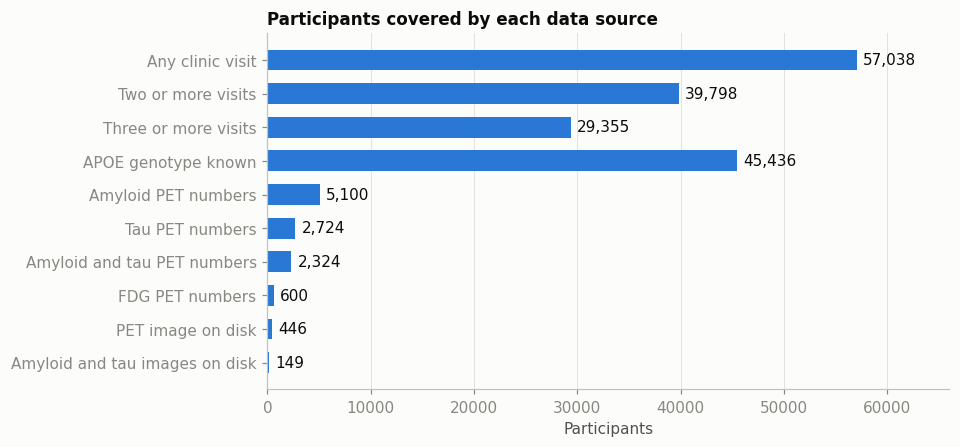

PET participants not present in the clinical table: {'amyloid': 312, 'tau': 210, 'FDG': 39}


In [3]:
uds = nu.load_uds(["NACCUDSD", "NACCAPOE", "NACCVNUM"])
ids = set(uds.NACCID)
amy, tau, fdg, img = nu.load_pet_amyloid(), nu.load_pet_tau(), nu.load_pet_fdg(), nu.load_pet_images()
n_visits = uds.groupby("NACCID").size()
apoe_known = set(uds.loc[uds.NACCAPOE.isin([1, 2, 3, 4, 5, 6]), "NACCID"])
A, T, F, I = (set(d.NACCID) & ids for d in (amy, tau, fdg, img))

coverage = pd.Series({
    "Any clinic visit": len(ids),
    "Two or more visits": int((n_visits >= 2).sum()),
    "Three or more visits": int((n_visits >= 3).sum()),
    "APOE genotype known": len(apoe_known),
    "Amyloid PET numbers": len(A),
    "Tau PET numbers": len(T),
    "Amyloid and tau PET numbers": len(A & T),
    "FDG PET numbers": len(F),
    "PET image on disk": len(I),
    "Amyloid and tau images on disk": len(set(img[img.folder_modality == "Amyloid"].NACCID) & set(img[img.folder_modality == "Tau"].NACCID)),
})
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(coverage.index[::-1], coverage.values[::-1], color=nu.BLUE, height=0.62)
for y, v in enumerate(coverage.values[::-1]):
    ax.text(v + 600, y, f"{v:,}", va="center", color=nu.INK)
ax.set_xlim(0, 66000); ax.grid(axis="y", visible=False)
ax.set_xlabel("Participants"); ax.set_title("Participants covered by each data source")
nu.savefig(fig, "01_participants_by_source"); plt.show()
print("PET participants not present in the clinical table:",
      {"amyloid": amy.NACCID.nunique() - len(A), "tau": tau.NACCID.nunique() - len(T), "FDG": fdg.NACCID.nunique() - len(F)})

**How to read this.**

* About 57,000 people have clinical data, and about 40,000 of them came back at least once. That is the cohort where longitudinal models are realistic.
* About 5,100 people have amyloid PET **numbers** (Centiloids and SUVRs already computed by the PET core), and about 2,700 have tau PET numbers.
* Only 446 people have a PET **image** on disk.

So "PET" means two very different things in this project: a table of numbers for thousands of people, and raw images for a few hundred. The plan treats them separately.

A few hundred PET participants do not appear in the clinical table at all (printed above). They cannot be used for prediction because we have no outcome for them.

## 3. The main clinical table

### 3.1 It is really several questionnaires glued together

The Uniform Data Set (UDS) is a set of forms that each centre fills in at every visit. The forms changed over time (versions 1, 2, 3 and now 4), and telephone visits use a shorter set. A variable is "missing" in three different ways, and they mean different things:

| What we see | What it means |
|---|---|
| `-4` | The form or question was not part of that visit (wrong version, telephone visit, optional module). Nobody forgot anything. |
| `8`, `88`, `888` | Not applicable or not assessed for this person. |
| `9`, `99`, `999` | Asked, but the answer is unknown. |

The chart below shows, for each kind of visit, what percentage of visits have each form.

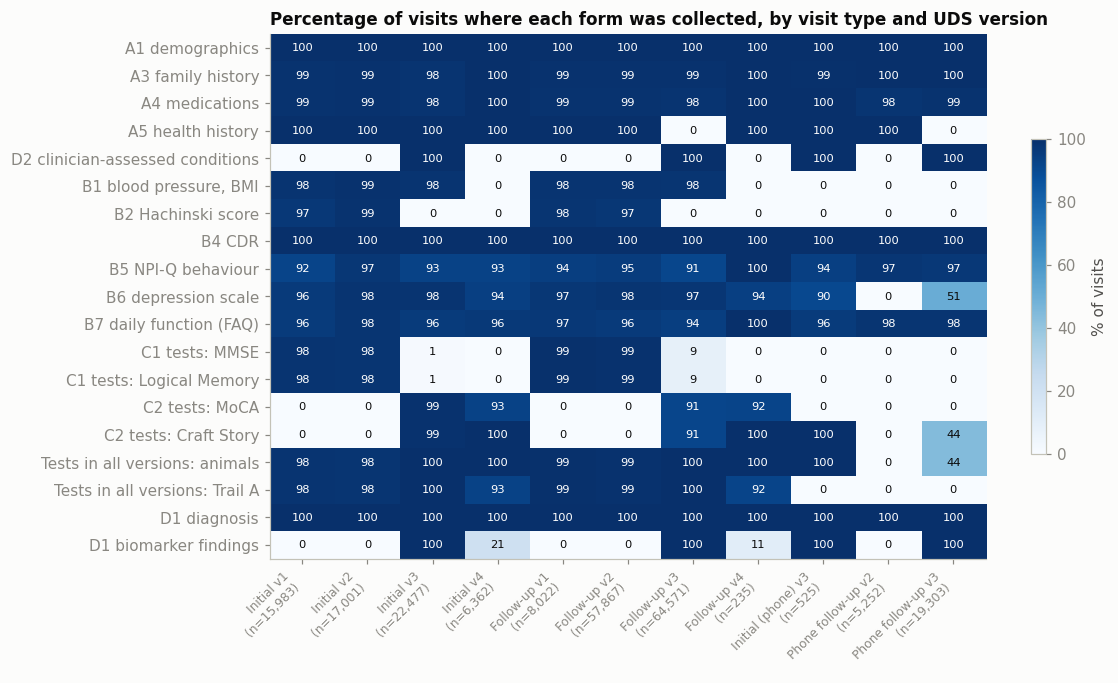

In [4]:
df = nu.load_uds(["PACKET", "FORMVER", "NACCSEX", "NACCFAM", "NACCAHTN", "HYPERTEN", "HYPERT", "BPSYS", "HACHIN",
                  "CDRSUM", "NACCUDSD", "NACCGDS", "BILLS", "DEL", "NACCMMSE", "LOGIMEM", "MOCATOTS", "CRAFTVRS",
                  "ANIMALS", "TRAILA", "AMYLPET"])
kind = df.PACKET.map({"I": "Initial", "I4": "Initial", "IT": "Initial (phone)", "F": "Follow-up", "T": "Phone follow-up"})
ver = df.FORMVER.map({1.0: "v1", 2.0: "v2", 3.0: "v3", 3.2: "v3", 4.0: "v4"})
df["Visit type"] = kind + " " + ver
forms = {"A1 demographics": "NACCSEX", "A3 family history": "NACCFAM", "A4 medications": "NACCAHTN",
         "A5 health history": "HYPERTEN", "D2 clinician-assessed conditions": "HYPERT", "B1 blood pressure, BMI": "BPSYS",
         "B2 Hachinski score": "HACHIN", "B4 CDR": "CDRSUM", "B5 NPI-Q behaviour": "DEL", "B6 depression scale": "NACCGDS",
         "B7 daily function (FAQ)": "BILLS", "C1 tests: MMSE": "NACCMMSE", "C1 tests: Logical Memory": "LOGIMEM",
         "C2 tests: MoCA": "MOCATOTS", "C2 tests: Craft Story": "CRAFTVRS", "Tests in all versions: animals": "ANIMALS",
         "Tests in all versions: Trail A": "TRAILA", "D1 diagnosis": "NACCUDSD", "D1 biomarker findings": "AMYLPET"}
order = ["Initial v1", "Initial v2", "Initial v3", "Initial v4", "Follow-up v1", "Follow-up v2", "Follow-up v3",
         "Follow-up v4", "Initial (phone) v3", "Phone follow-up v2", "Phone follow-up v3"]
cov = pd.DataFrame({f: (df[c] != -4).groupby(df["Visit type"]).mean() * 100 for f, c in forms.items()}).T[order]
n_by = df["Visit type"].value_counts()[order]

fig, ax = plt.subplots(figsize=(10.5, 6.2))
im = ax.imshow(cov.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(order)), [f"{o}\n(n={n_by[o]:,})" for o in order], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(cov)), cov.index); ax.grid(False)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5, color="white" if v > 55 else nu.INK)
ax.set_title("Percentage of visits where each form was collected, by visit type and UDS version")
fig.colorbar(im, ax=ax, shrink=0.6, label="% of visits")
nu.savefig(fig, "01_form_coverage"); plt.show()

**What this tells us, and why each point matters for the model.**

1. **CDR and diagnosis are in every visit of every version.** That is why they are the safest choice of outcome.
2. **The test battery changed in version 3.** MMSE and Logical Memory stop; MoCA and Craft Story start. A model cannot simply use "MMSE" for everyone. Only a few tests (animals, vegetables, Trail Making A and B) run through all versions. Notebook 03 comes back to this.
3. **Health history (form A5) is not repeated at version 3 follow-up visits.** It was replaced there by the clinician form D2. So "hypertension" comes from two different forms depending on the visit, and the two must be combined into one feature during cleaning.
4. **Blood pressure is measured at in-person visits only**, and under version 4 it is stored in new variables (left and right arm) that are still more than 90% empty in this file.
5. **Telephone visits have no cognitive tests**, only CDR, function and diagnosis.

### 3.2 Why 2,649 columns is far fewer than it sounds

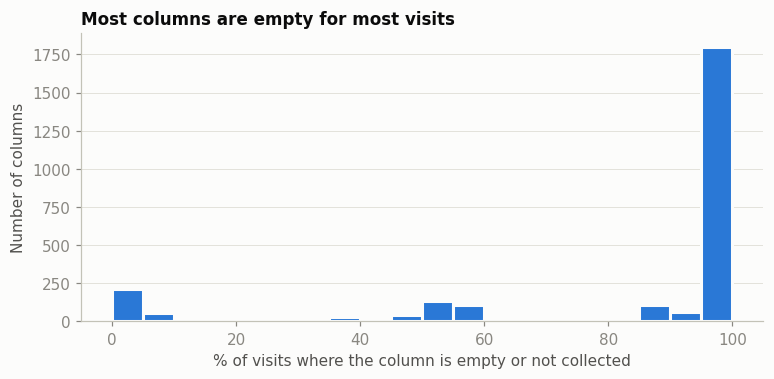

,columns,with_data_in_10pct_of_visits
block,,
FTLD module,483,2
LBD module,400,1
Medication names and codes,80,12
Neuropathology (autopsy),189,78
UDS forms (versions 1-4),1497,694
Total,2649,787


In [5]:
per_col = pd.DataFrame(next(t for t in audit["tables"] if "ftldlbd" in t["file"])["missingness"]["per_column"]).T
miss = per_col["blank_or_coded_pct"].astype(float)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(miss, bins=np.arange(0, 101, 5), color=nu.BLUE, edgecolor="#fcfcfb", linewidth=2)
ax.set_xlabel("% of visits where the column is empty or not collected"); ax.set_ylabel("Number of columns")
ax.set_title("Most columns are empty for most visits"); ax.grid(axis="x", visible=False)
nu.savefig(fig, "01_column_missingness"); plt.show()

def block(name):
    for prefix, label in [("FTD", "FTLD module"), ("LB", "LBD module"), ("NP", "Neuropathology (autopsy)"), ("NACCWRI", "Neuropathology (autopsy)"),
                          ("RXNORM", "Medication names and codes"), ("DRUG", "Medication names and codes")]:
        if name.startswith(prefix):
            return label
    return "UDS forms (versions 1-4)"
groups = pd.DataFrame({"block": [block(c) for c in miss.index], "usable": (miss <= 90).values})
summary = groups.groupby("block").agg(columns=("usable", "size"), with_data_in_10pct_of_visits=("usable", "sum"))
summary.loc["Total"] = summary.sum()
summary

Roughly 1,860 of the 2,649 columns are empty in more than 90% of visits. They belong to:

* the **FTLD and LBD modules**, extra forms given only to people suspected of frontotemporal or Lewy body disease;
* **neuropathology**, which exists only for people who died and had an autopsy (fewer than one in five rows);
* **UDS version 4** items, which only started recently (about 3% of visits);
* free-text and medication-name columns.

None of these is a mistake in the data. They are simply not relevant to most people. For this project we work with the columns that have data in at least 10% of visits (787 columns), and from those we pick a much shorter list on purpose.

**Neuropathology is a special case.** It is the "ground truth" of what disease someone had, but it is only known after death. It must never be a model input. It could be used later as an extra check on a subset.

### 3.3 A missing code is not the same number for every variable

This is the most common way to get NACC cleaning wrong. The value 88 is a real age, but for "years smoked" it means "not applicable (never smoked)". If we replaced every 88 with missing, we would delete every 88-year-old.

In [6]:
chk = nu.load_uds(["NACCAGE", "SMOKYRS", "BPDIAS", "NACCMMSE"])
demo = pd.DataFrame({
    "Variable": ["NACCAGE (age)", "BPDIAS (diastolic pressure)", "SMOKYRS (years smoked)", "NACCMMSE (MMSE score)"],
    "Visits with the value 88": [(chk.NACCAGE == 88).sum(), (chk.BPDIAS == 88).sum(), (chk.SMOKYRS == 88).sum(), (chk.NACCMMSE == 88).sum()],
    "What 88 means there": ["88 years old (a real value)", "88 mmHg (a real value)", "Not applicable: never smoked", "Test not given"],
})
demo.style.format({"Visits with the value 88": "{:,}"}).hide(axis="index")

Variable,Visits with the value 88,What 88 means there
NACCAGE (age),"3,655",88 years old (a real value)
BPDIAS (diastolic pressure),"3,090",88 mmHg (a real value)
SMOKYRS (years smoked),"73,669",Not applicable: never smoked
NACCMMSE (MMSE score),88,Test not given


So the project keeps a **variable map** (`scripts/nacc_utils.py`, the `VARIABLES` dictionary) that lists, for each variable we use, its own missing codes. The function `nu.clean()` applies them one variable at a time. Nothing is cleaned globally.

## 4. The variable map

The project brief names five groups of information. The map below assigns each chosen NACC variable to one group, plus two extra groups we need for modelling: the longitudinal structure (who, when) and the outcomes (what we might predict).

Each variable also has a **role**:

* **predictor**: a candidate model input.
* **outcome**: something we may predict. A *future* value of an outcome must never be an input.
* **proximal**: a clinician judgement that is very close to the diagnosis itself (for example, "level of independence" or the daily-function questionnaire). It is allowed as an input at the index visit, but it can make the model look clever when it is only repeating what the doctor already concluded. You need to decide, and justify, whether to keep these.
* **structure / id / context**: used to organise or describe the data, not as inputs.

In [7]:
vm = pd.DataFrame(nu.VARIABLES).T
vm.index.name = "variable"
pd.crosstab(vm.category, vm.role, margins=True, margins_name="Total")

role,context,id,outcome,predictor,proximal,structure,Total
category,,,,,,,
Cardiovascular / medical,3,0,0,36,0,0,39
Cognitive,0,0,0,21,13,0,34
Demographics,1,0,0,9,2,0,12
Genetics / APOE,2,0,0,5,0,0,7
Longitudinal structure,2,1,0,0,0,7,10
Outcomes,0,0,12,0,0,0,12
Total,8,1,12,71,15,7,114


In [8]:
# Coverage of each mapped variable: how often do we actually have a valid value?
cols = [c for c in vm.index if c not in ("NACCID", "VISITDATE")]
full = nu.clean(nu.load_uds(cols + ["NACCVNUM"]))
base = full[full.NACCVNUM == 1]
vm["visits_valid_pct"] = [np.nan if c in ("NACCID", "VISITDATE") else round(full[c].notna().mean() * 100, 1) for c in vm.index]
vm["first_visit_valid_pct"] = [np.nan if c in ("NACCID", "VISITDATE") else round(base[c].notna().mean() * 100, 1) for c in vm.index]
vm.loc[["NACCID", "VISITDATE"], ["visits_valid_pct", "first_visit_valid_pct"]] = 100.0

lines = ["# Variable map", "",
         "Generated by `notebooks/01_data_catalogue.ipynb` from the `VARIABLES` dictionary in `scripts/nacc_utils.py`.",
         "Aggregate figures only. Meanings follow the NACC UDS Researcher's Data Dictionary; confirm each one against the Freeze 74 RDD before citing it.", "",
         f"Base: {len(full):,} visits from {full.NACCID.nunique():,} participants in `investigator_ftldlbd_nacc74.csv`.", "",
         "Roles: **predictor** = candidate input; **outcome** = what we may predict (a future value is never an input); "
         "**proximal** = clinician judgement close to the diagnosis, keep only with a stated reason; "
         "**structure / id / context** = not an input.", ""]
for cat in [nu.LONG, nu.OUT, nu.DEM, nu.GEN, nu.CV, nu.COG]:
    sub = vm[vm.category == cat]
    lines += [f"## {cat}", "", "| Variable | Meaning | Group | Form | Type | Role | Codes | Missing codes | Valid in visits | Valid at first visit |",
              "|---|---|---|---|---|---|---|---|---|---|"]
    for name, r in sub.iterrows():
        lines.append(f"| `{name}` | {r.meaning} | {r.subgroup} | {r.form} | {r.kind} | {r.role} | {r.codes} | "
                     f"{', '.join(str(m) for m in r.missing)} | {r.visits_valid_pct}% | {r.first_visit_valid_pct}% |")
    lines.append("")
lines += ["## PET", "", "PET variables live in the SCAN and mixed-protocol tables, one row per scan. Coverage is in `notebooks/04_pet.ipynb`.", "",
          "| Variable (common name) | Meaning |", "|---|---|"] + [f"| `{k}` | {v} |" for k, v in nu.PET_VARIABLES.items()]
text = "\n".join(lines) + "\n"
nu.assert_no_ids(text, "variable map")
(nu.REPORTS / "variable_map.md").write_text(text, encoding="utf-8")
print("Wrote reports/variable_map.md with", len(vm), "clinical variables")

Wrote reports/variable_map.md with 114 clinical variables


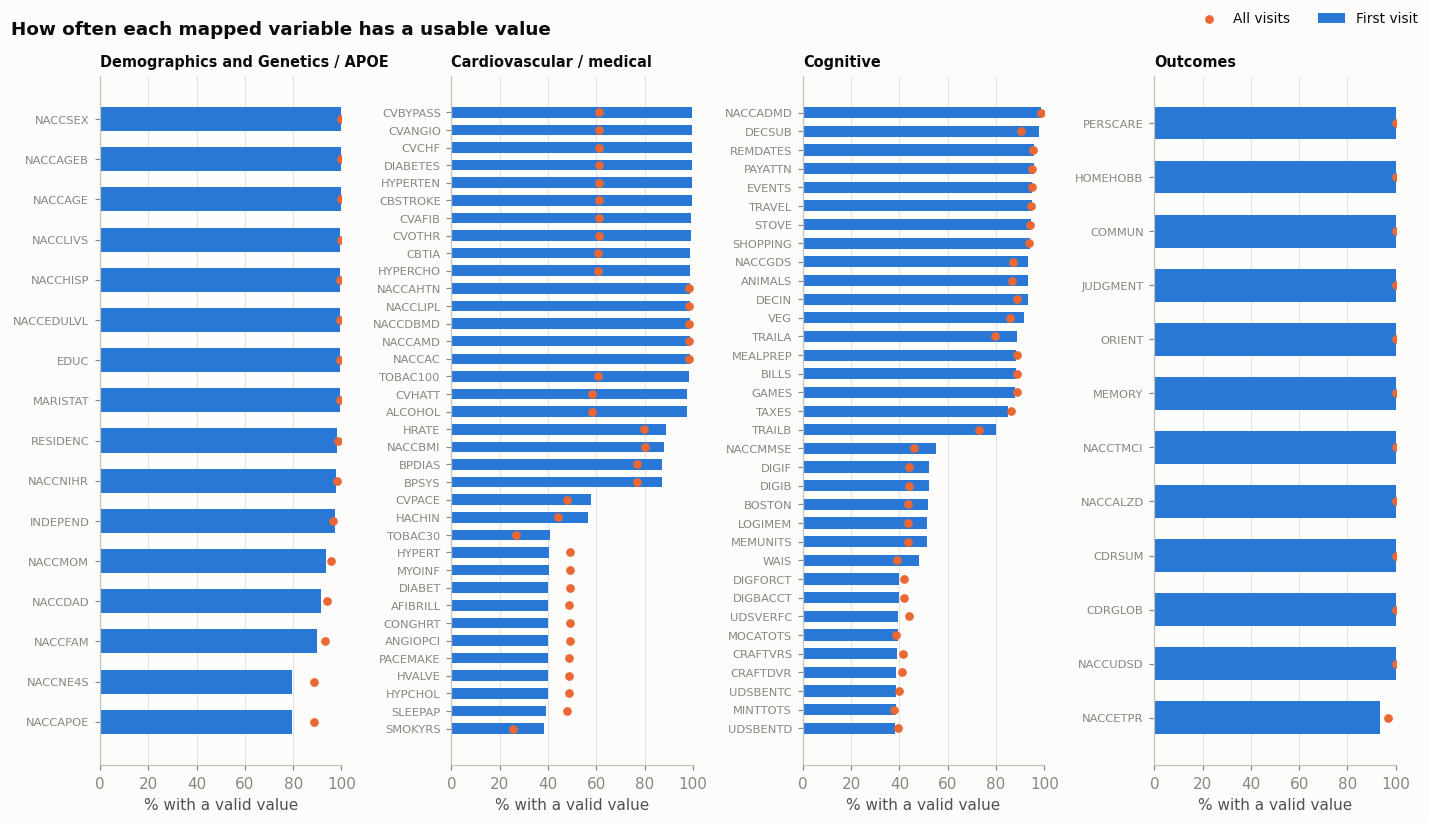

In [9]:
show = vm[vm.role.isin(["predictor", "proximal", "outcome"])].copy()
fig, axes = plt.subplots(1, 4, figsize=(13, 7.5), gridspec_kw={"width_ratios": [1, 1, 1, 1]})
for ax, cat in zip(axes, [nu.DEM + "|" + nu.GEN, nu.CV, nu.COG, nu.OUT]):
    sub = show[show.category.isin(cat.split("|"))].sort_values("first_visit_valid_pct")
    ax.barh(sub.index, sub.first_visit_valid_pct, color=nu.BLUE, height=0.6, label="First visit")
    ax.scatter(sub.visits_valid_pct, sub.index, color=nu.ORANGE, s=22, zorder=3, label="All visits")
    ax.set_xlim(0, 100); ax.set_title(cat.replace("|", " and "), fontsize=9.5); ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", labelsize=7.5); ax.set_xlabel("% with a valid value")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, fontsize=9)
fig.suptitle("How often each mapped variable has a usable value", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "01_variable_coverage"); plt.show()

**Reading the coverage chart.** The bar is the first visit; the dot is all visits.

* Variables near 100% (demographics, CDR, diagnosis, medications, fluency tests) are safe to build on.
* Variables near 40-50% are the version-specific ones (MMSE or MoCA, form D2). They are not "bad"; each exists for about half the visits because of the version change. They need to be **harmonised** (combined into one feature) rather than dropped.
* Health history from form A5 is almost complete at the first visit but present in only about 60% of all visits, because it is not repeated at version 3 follow-ups.
* APOE is known for about 80% of people.

The full table is saved as `reports/variable_map.md`.

## 5. What you should take from this notebook

1. The clinical table is the backbone: 57,038 people, 217,598 visits, with CDR and diagnosis at every visit.
2. PET numbers exist for about 5,100 people (amyloid) and 2,700 (tau). PET images exist for 446.
3. Missing values have three meanings, and the codes differ per variable. Cleaning is done per variable using the variable map.
4. The UDS changed over time. Any feature that exists in only one version must be harmonised before modelling.

### Decisions for the team

* **Which "proximal" variables to keep as inputs** (independence, FAQ, memory complaint, Alzheimer's medication). Keeping them raises accuracy but weakens the claim of *early* prediction.
* **Whether to include UDS version 4 visits.** They are recent (3% of visits) and use new variable names for blood pressure and history, so they need extra mapping work for little data.
* **Whether to add more variables to the map.** The map is deliberately short. Anything added needs a meaning from the RDD, its own missing codes, and a reason for belonging to a category.